In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
sns.set_style("whitegrid")

In [3]:
from config import DB_CONFIG

engine = create_engine(
    f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
)

#### 1. Load data from PostgreSQL (not from the CSV directly — proves the DB round-trip works)

In [4]:
df = pd.read_sql("SELECT * FROM transactions;", engine)
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
df.head()

Loaded 284,807 rows, 32 columns


,id,tx_time,amount,v1,v2,v3,v4,v5,v6,v7,...,v20,v21,v22,v23,v24,v25,v26,v27,v28,class
0,1,0.0,149.62,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,2,0.0,2.69,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,3,1.0,378.66,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,4,1.0,123.50,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,5,2.0,69.99,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 32 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       284807 non-null  int64  
 1   tx_time  284807 non-null  float64
 2   amount   284807 non-null  float64
 3   v1       284807 non-null  float64
 4   v2       284807 non-null  float64
 5   v3       284807 non-null  float64
 6   v4       284807 non-null  float64
 7   v5       284807 non-null  float64
 8   v6       284807 non-null  float64
 9   v7       284807 non-null  float64
 10  v8       284807 non-null  float64
 11  v9       284807 non-null  float64
 12  v10      284807 non-null  float64
 13  v11      284807 non-null  float64
 14  v12      284807 non-null  float64
 15  v13      284807 non-null  float64
 16  v14      284807 non-null  float64
 17  v15      284807 non-null  float64
 18  v16      284807 non-null  float64
 19  v17      284807 non-null  float64
 20  v18      284807 non-null  float64
 21

In [6]:
df.describe()

,id,tx_time,amount,v1,v2,v3,v4,v5,v6,v7,...,v20,v21,v22,v23,v24,v25,v26,v27,v28,class
count,284807.000000,284807.000000,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000
mean,142404.000000,94813.859575,88.349619,1.200708e-15,3.353041e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.500885e-15,-5.620335e-16,...,6.418678e-16,1.596686e-16,-3.321107e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.684504e-15,-3.663396e-16,-1.223461e-16,0.001727
std,82216.843396,47488.145955,250.120109,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,...,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,0.041527
min,1.000000,0.000000,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,...,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000
25%,71202.500000,54201.500000,5.600000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,...,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,0.000000
50%,142404.000000,84692.000000,22.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,...,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,0.000000
75%,213605.500000,139320.500000,77.165000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,...,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,0.000000
max,284807.000000,172792.000000,25691.160000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,...,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,1.000000


#### 2. Class balance
##### This is the single most important fact about this dataset — extreme imbalance.
Adding (normalize=True) inside the parentheses tells Pandas to return the relative frequency (a decimal between 0.0 and 1.0) instead of the raw count.

class
0    284315
1       492
Name: count, dtype: int64
class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


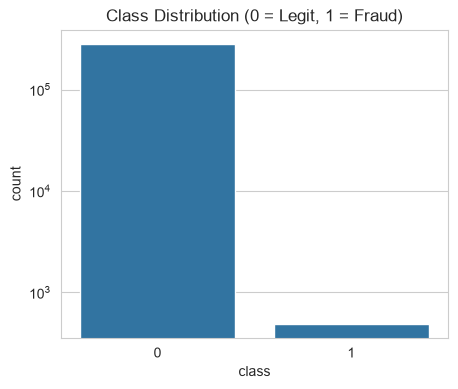

In [7]:
class_counts = df["class"].value_counts()
class_pct = df["class"].value_counts(normalize=True) * 100
print(class_counts)
print(class_pct)

plt.figure(figsize=(5, 4))
sns.countplot(x="class", data=df)
plt.title("Class Distribution (0 = Legit, 1 = Fraud)")
plt.yscale("log")  # log scale since the imbalance is so extreme
plt.show()

#### 3. Transaction amount: fraud vs. legit
##### Does fraud tend to involve different amounts than normal transactions?

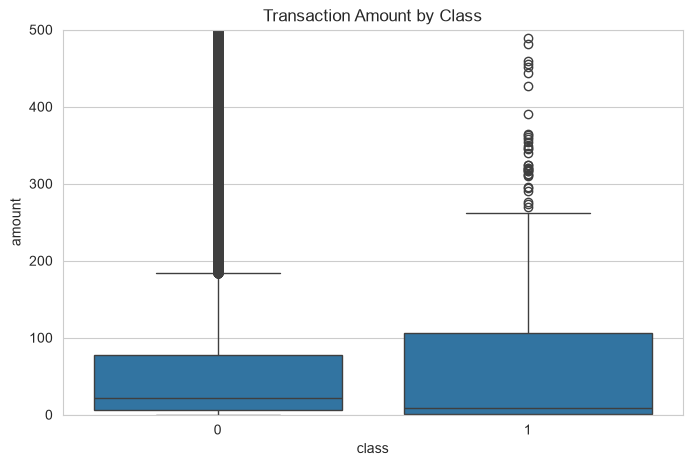

          count        mean         std  min   25%    50%     75%       max
class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="class", y="amount", data=df)
plt.title("Transaction Amount by Class")
plt.ylim(0, 500)  # zoom in; there are extreme outliers otherwise
plt.show()
 
print(df.groupby("class")["amount"].describe())

#### 4. Time patterns
##### `tx_time` is seconds elapsed since the first transaction in the dataset (spans about 2 days). Convert to hour-of-day to see if fraud clusters at certain times.

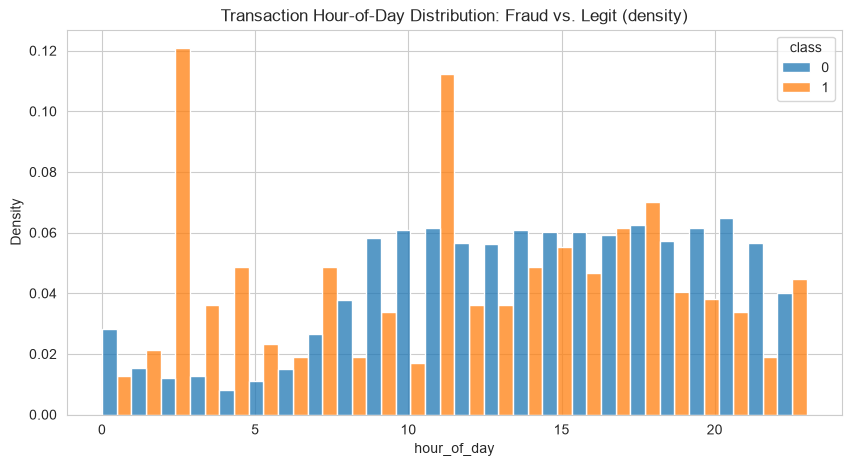

In [9]:
df["hour_of_day"] = (df["tx_time"] // 3600) % 24
 
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df, x="hour_of_day", hue="class", stat="density",
    common_norm=False, bins=24, multiple="dodge"
)
plt.title("Transaction Hour-of-Day Distribution: Fraud vs. Legit (density)")
plt.show()

#### 5. Correlation of V1-V28 features with the fraud label
##### Since V1-V28 are PCA components, we can't interpret them individually, but we CAN see which ones separate fraud from legit most strongly this previews what SHAP will likely highlight later.

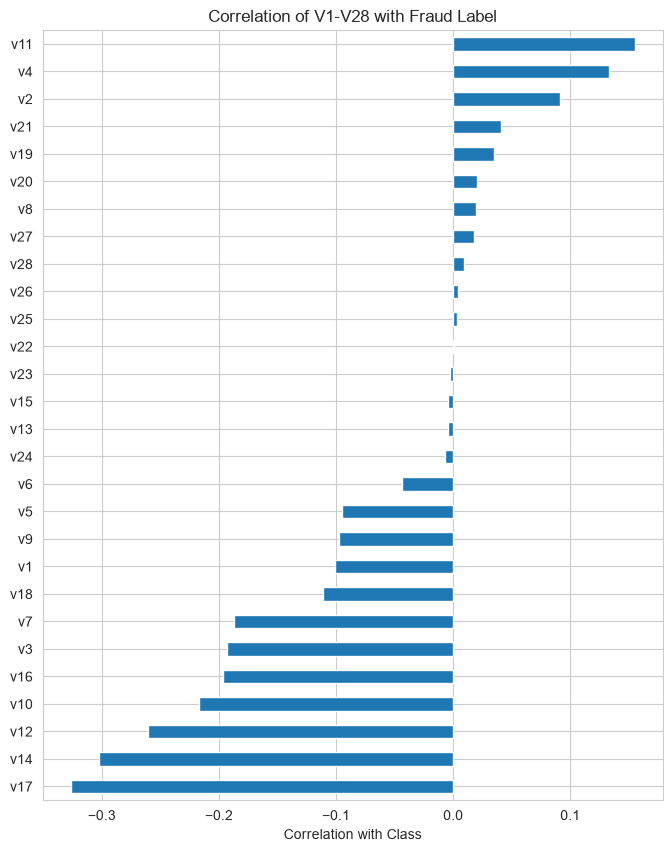

Top 5 positively correlated:
v19    0.034783
v21    0.040413
v2     0.091289
v4     0.133447
v11    0.154876
Name: class, dtype: float64

Top 5 negatively correlated:
v17   -0.326481
v14   -0.302544
v12   -0.260593
v10   -0.216883
v16   -0.196539
Name: class, dtype: float64


In [10]:
v_cols = [f"v{i}" for i in range(1, 29)]
correlations = df[v_cols + ["class"]].corr()["class"].drop("class").sort_values()
 
plt.figure(figsize=(8, 10))
correlations.plot(kind="barh")
plt.title("Correlation of V1-V28 with Fraud Label")
plt.xlabel("Correlation with Class")
plt.show()
 
print("Top 5 positively correlated:")
print(correlations.tail(5))
print("\nTop 5 negatively correlated:")
print(correlations.head(5))

#### 6. Summary notes (fill these in as you observe the plots)
##### - Class imbalance ratio: 0.17% fraud
##### - Fraud amounts tend to be: (higher/lower/similar) vs legit: While fraud might have a higher mean in some samples, the median fraud transaction is typically for a smaller amount than a legitimate one.
##### - Fraud clusters around hour(s): 2am to 4am and 11am to 1pm
##### - Most separating features: Top 5 positively correlated: v19, v21, v2, v4, v11 || Top 5 negatively correlated: v16, v10, v12, v14, v17
#####
###### These observations will guide feature engineering and model evaluation choices in the next steps.